In this notebook, we will implement a DNN classifier to classify the airplanes and automobiles from the CIFAR10 dataset. You can learn more about the dataset (https://www.cs.toronto.edu/~kriz/cifar.html)

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [20, 6]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

Dataset Loading

Let's load the CIFAR10 dataset and filter the airplanes and cars.

In [8]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

# Flatten the labels
y_train = y_train.flatten()
y_test = y_test.flatten()

# Filtering for planes and cars
mask_train = np.logical_or(y_train == 0, y_train == 1)
x_train = x_train[mask_train, ...]
y_train = y_train[mask_train]

mask_test = np.logical_or(y_test == 0, y_test == 1)
x_test = x_test[mask_test, ...]
y_test = y_test[mask_test]

print('\nPlanes & Cars')
print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 46s 0us/step
Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)

Planes & Cars
Train set:    10000 samples
Test set:     2000 samples
Sample dims:  (10000, 32, 32, 3)


This dataset contains RGB images. In order to simplify the problem, and for the sake of this demo, we will average the channels to generate gray-level-like images.

In [11]:
x_train = np.mean(x_train, axis=-1)
x_test = np.mean(x_test, axis=-1)

# Normalization
x_train = x_train/255
x_test = x_test/255

Data Visualisation

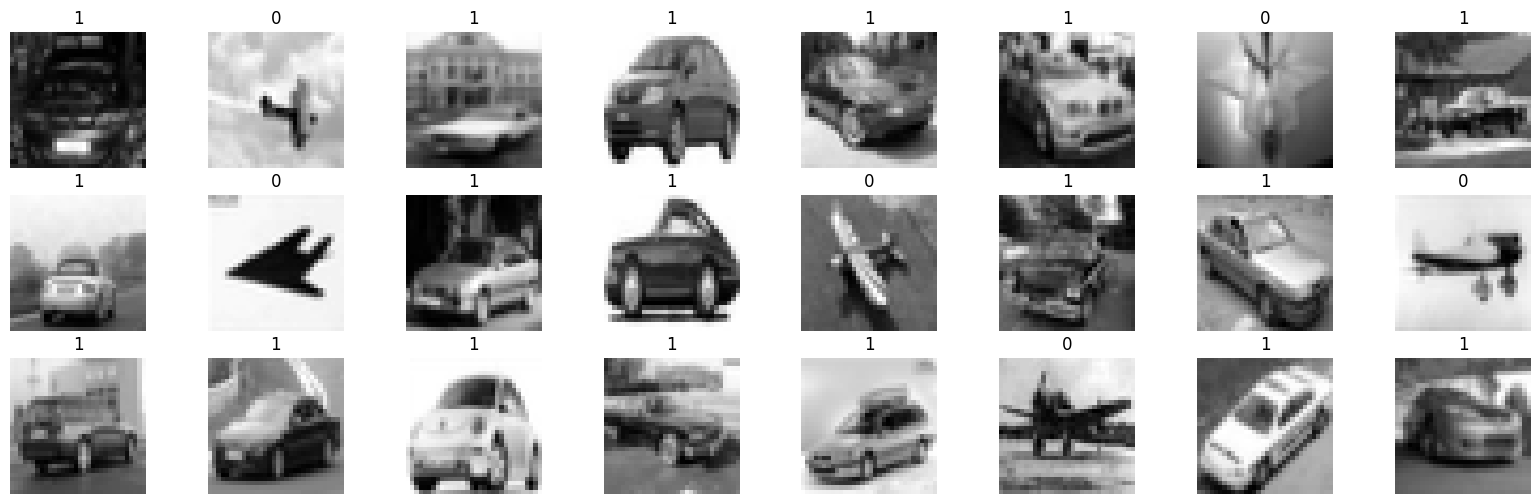

In [16]:
for ii in range(24):
    idx = np.random.randint(0, len(y_train))
    plt.subplot(3,8,ii+1), plt.imshow(x_train[idx, ...], cmap='gray'), plt.title(y_train[idx]), plt.axis(False)

In [20]:
inputs = Input(shape=(size, size, 1))

net = Flatten()(inputs)
net = Dense(16, activation='relu')(net)  
outputs = Dense(1, activation='linear')(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        16,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,417 (64.13 KB)

 Trainable params: 16,417 (64.13 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
epochs = 25
batch_size = 128

model.compile(loss="mse", optimizer="adam", metrics=["accuracy"])

start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('Elapsed time', time() - start)

Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5478 - loss: 0.2879 - val_accuracy: 0.6390 - val_loss: 0.2260
Epoch 2/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6841 - loss: 0.2107 - val_accuracy: 0.6910 - val_loss: 0.2041
Epoch 3/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7074 - loss: 0.1986 - val_accuracy: 0.7140 - val_loss: 0.1946
Epoch 4/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7248 - loss: 0.1892 - val_accuracy: 0.7200 - val_loss: 0.1884
Epoch 5/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7360 - loss: 0.1826 - val_accuracy: 0.7300 - val_loss: 0.1825
Epoch 6/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7479 - loss: 0.1765 - val_accuracy: 0.7410 - val_loss: 0.1770
Epoch 7/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7564 - loss: 0.1712 - val_accuracy: 0.7410 - val_loss: 0.1736
Epoch 8/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7622 - loss: 0.1684 - val_accuracy: 0.7510 - val_loss:

Train Acc      0.8062222003936768
Validation Acc 0.8019999861717224


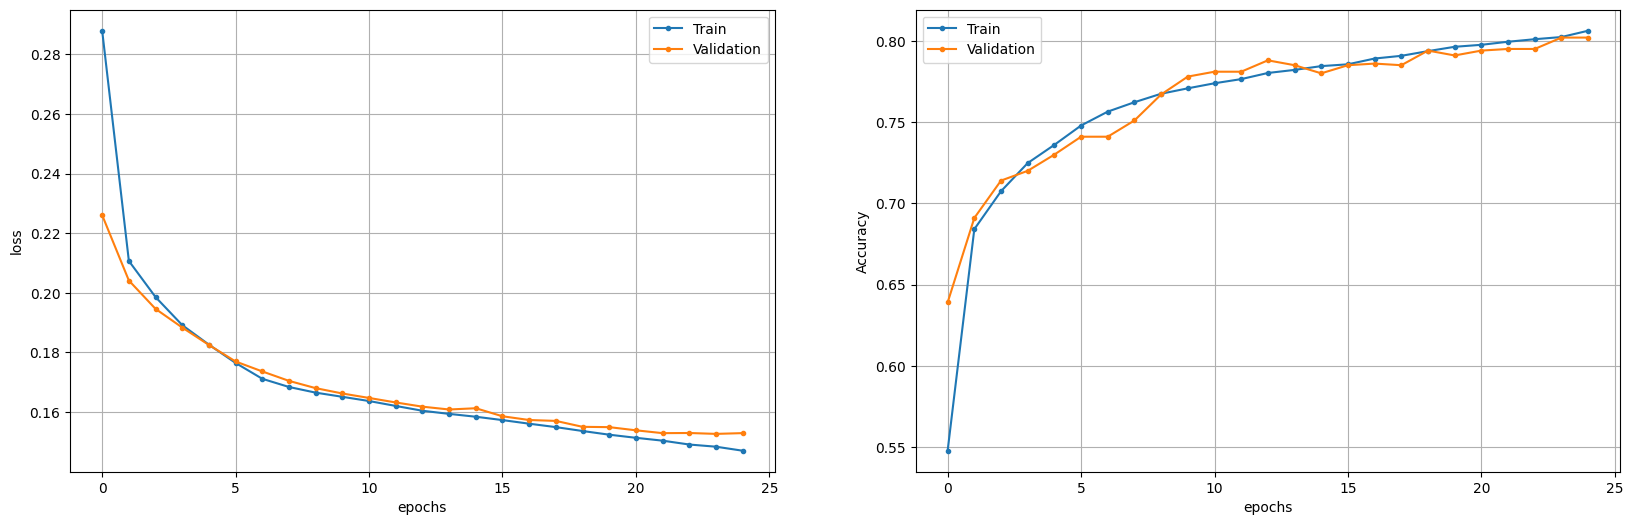

In [24]:
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                            epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
    
print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

In [26]:
y_pred = model.predict(x_test)

print('True', y_test[0:5].flatten())
print('Pred', y_pred[0:5].flatten())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
True [0 1 1 0 0]
Pred [0.4268448  0.47874984 0.7568284  0.33893877 0.14021513]


In [28]:
y_true = y_test.flatten()
y_pred = y_pred.flatten() > 0.5

# Overall accuracy
num_samples = len(y_true)
acc = np.sum(y_test == y_pred)/num_samples

# Accuracy for digit 0
mask = y_true == 0
acc0 = np.sum(y_test[mask] == y_pred[mask])/np.sum(mask)

# Accuracy for digit 1
mask = y_true == 1
acc1 = np.sum(y_test[mask] == y_pred[mask])/np.sum(mask)

print('Overall acc', acc)
print('Digit-0 acc', acc0)
print('Digit-1 acc', acc1)

Overall acc 0.793
Digit-0 acc 0.8
Digit-1 acc 0.786


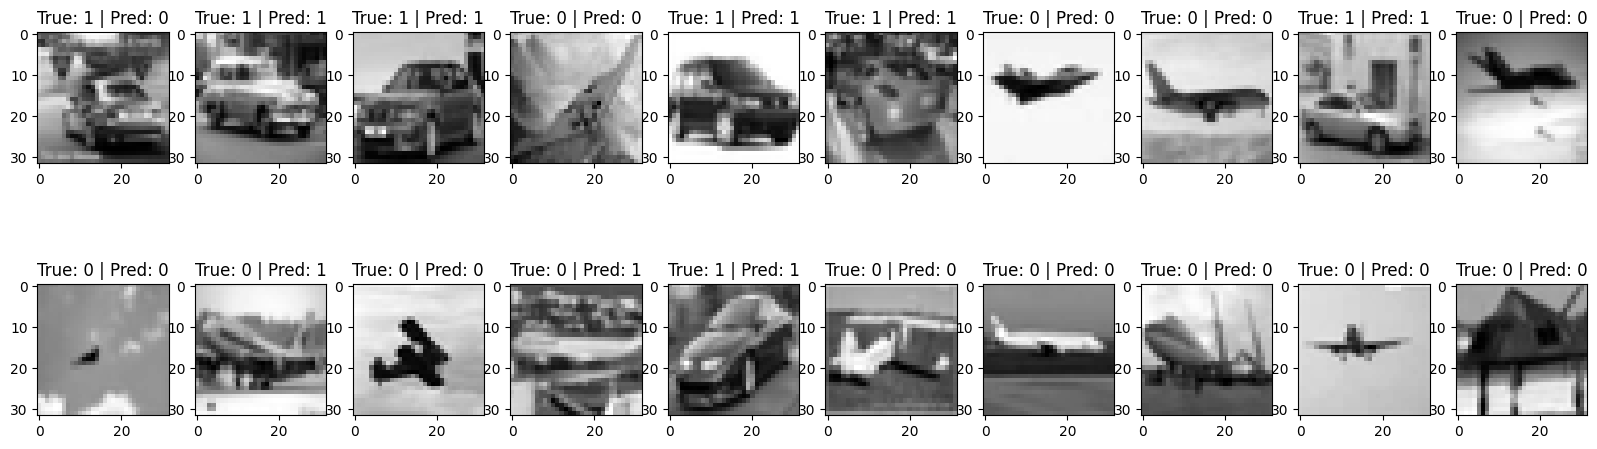

In [34]:
for ii in range(20):
    idx = np.random.randint(0, len(y_pred))
    plt.subplot(2,10,ii+1), plt.imshow(x_test[idx, ...], cmap='gray')
    plt.title('True: ' + str(y_true[idx]) + ' | Pred: ' + str(int(y_pred[idx])))